In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("renpho_clean.csv")

df.head()

,measurement_timestamp,measurement_date,measurement_time,weight_lb,bmi,body_fat_pct,fat_free_body_weight_lb,subcutaneous_fat_pct,visceral_fat,body_water_pct,skeletal_muscle_pct,muscle_mass_lb,bone_mass_lb,protein_pct,bmr_kcal,metabolic_age
0,2026-06-26 08:49:04.000 -0400,2026-06-26,08:49:04,171.6,24.6,14.7,146.2,12.6,7.0,61.6,55.1,138.8,7.4,19.4,1802.0,20.0
1,2026-06-25 08:15:12.000 -0400,2026-06-25,08:15:12,170.8,24.5,14.7,145.8,12.6,7.0,61.6,55.1,138.4,7.2,19.5,1798.0,19.0
2,2026-06-24 08:25:29.000 -0400,2026-06-24,08:25:29,170.4,24.4,14.6,145.6,12.5,7.0,61.6,55.2,138.2,7.2,19.5,1795.0,19.0
3,2026-06-23 08:23:04.000 -0400,2026-06-23,08:23:04,171.2,24.5,14.7,146.2,12.6,7.0,61.6,55.1,138.8,7.2,19.4,1801.0,20.0
4,2026-06-22 09:13:16.000 -0400,2026-06-22,09:13:16,170.6,24.4,14.6,145.6,12.5,7.0,61.6,55.2,138.2,7.2,19.5,1796.0,19.0


In [5]:
df["measurement_date"] = pd.to_datetime(df["measurement_date"])

df = df.sort_values("measurement_date")

df.info()

<class 'pandas.DataFrame'>
Index: 1301 entries, 1300 to 0
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   measurement_timestamp    1301 non-null   str           
 1   measurement_date         1301 non-null   datetime64[us]
 2   measurement_time         1301 non-null   str           
 3   weight_lb                1301 non-null   float64       
 4   bmi                      1301 non-null   float64       
 5   body_fat_pct             1224 non-null   float64       
 6   fat_free_body_weight_lb  1224 non-null   float64       
 7   subcutaneous_fat_pct     1224 non-null   float64       
 8   visceral_fat             1224 non-null   float64       
 9   body_water_pct           1224 non-null   float64       
 10  skeletal_muscle_pct      1224 non-null   float64       
 11  muscle_mass_lb           1224 non-null   float64       
 12  bone_mass_lb             1224 non-null   float64  

In [6]:
daily_weight = (
    df.groupby("measurement_date", as_index=False)
      .agg(
          avg_daily_weight_lb=("weight_lb", "mean"),
          measurement_count=("weight_lb", "count")
      )
)

daily_weight["rolling_7_day_avg_weight"] = (
    daily_weight["avg_daily_weight_lb"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_weight.head()

,measurement_date,avg_daily_weight_lb,measurement_count,rolling_7_day_avg_weight
0,2020-08-26,139.0,1,139.000000
1,2020-08-27,138.2,1,138.600000
2,2020-08-28,140.2,1,139.133333
3,2020-08-29,137.6,1,138.750000
4,2020-08-30,139.2,1,138.840000


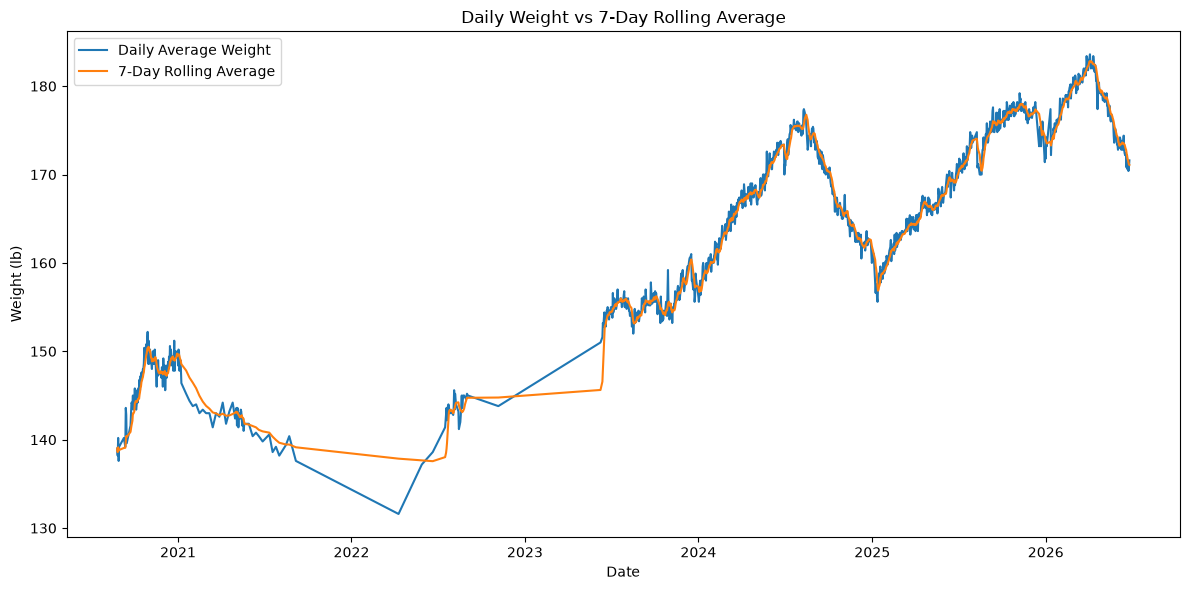

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_weight["measurement_date"],
    daily_weight["avg_daily_weight_lb"],
    label="Daily Average Weight"
)

plt.plot(
    daily_weight["measurement_date"],
    daily_weight["rolling_7_day_avg_weight"],
    label="7-Day Rolling Average"
)

plt.title("Daily Weight vs 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weight (lb)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
def label_phase(date):
    if pd.Timestamp("2023-11-20") <= date <= pd.Timestamp("2024-08-04"):
        return "Bulk 1 - Estimated"
    elif pd.Timestamp("2024-08-26") <= date <= pd.Timestamp("2024-12-15"):
        return "Cut 1 - Estimated"
    elif pd.Timestamp("2025-02-01") <= date <= pd.Timestamp("2026-04-14"):
        return "Bulk 2"
    elif pd.Timestamp("2026-04-15") <= date <= pd.Timestamp("2026-07-15"):
        return "Cut 2"
    else:
        return "Transition / Unlabeled"

daily_weight["fitness_phase"] = daily_weight["measurement_date"].apply(label_phase)

daily_weight.head()

,measurement_date,avg_daily_weight_lb,measurement_count,rolling_7_day_avg_weight,fitness_phase
0,2020-08-26,139.0,1,139.000000,Transition / Unlabeled
1,2020-08-27,138.2,1,138.600000,Transition / Unlabeled
2,2020-08-28,140.2,1,139.133333,Transition / Unlabeled
3,2020-08-29,137.6,1,138.750000,Transition / Unlabeled
4,2020-08-30,139.2,1,138.840000,Transition / Unlabeled
